In [1]:
import pandas as pd
import sqlite3

In [2]:
pd.set_option('display.max_columns', None)

## Ex02
Сделай всё необходимое, чтобы получить график как на примере:
- Анализируй только пользователей (не учитывай админов).
- Размер шрифта и размер фигуры — те же, что раньше.
- Интервалы времени суток:
    - night (ночь) — с 0:00:00 до 03:59:59,
    - morning (утро) — с 04:00:00 до 09:59:59,
    - afternoon (день) — с 10:00:00 до 16:59:59,
    - evening (вечер) — с 17:00:00 до 23:59:59.
- Палитру выбери на свой вкус — повторять цвета из примера не требуется.
- В конце блокнота добавь markdown-ячейку и вставь вопросы:
    - «Когда наши пользователи обычно коммитят: ночью, утром, днём или вечером?» — в ответе укажи две самые частые категории.
    - «Какой день имел максимальное число коммитов и при этом вечером коммитов больше, чем днём?»
    
    В ответе должна стоять дата этого дня.

In [3]:
db_path = '../data/checking-logs.sqlite'
conn = sqlite3.connect(db_path)

In [4]:
commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user%' 
    """,
    conn,
    parse_dates=['timestamp']
)

print('===Данные по коммитам===')
commits

===Данные по коммитам===


,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [5]:
commits['hour'] = commits['timestamp'].dt.hour
commits['date'] = commits['timestamp'].dt.date
commits

,uid,timestamp,hour,date
0,user_4,2020-04-17 05:19:02.744528,5,2020-04-17
1,user_4,2020-04-17 05:22:35.249331,5,2020-04-17
2,user_4,2020-04-17 05:22:45.549397,5,2020-04-17
3,user_4,2020-04-17 05:34:14.691200,5,2020-04-17
4,user_4,2020-04-17 05:34:24.422370,5,2020-04-17
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,20,2020-05-21
3203,user_1,2020-05-21 20:22:41.785725,20,2020-05-21
3204,user_1,2020-05-21 20:22:41.877806,20,2020-05-21
3205,user_1,2020-05-21 20:37:00.129678,20,2020-05-21


In [6]:
bins = [0, 4, 10, 17, 24]
labels = ['night', 'morning', 'afternoon', 'evening']

commits['daytime'] = pd.cut(commits['hour'], bins=bins, labels=labels, right=False)
commits

,uid,timestamp,hour,date,daytime
0,user_4,2020-04-17 05:19:02.744528,5,2020-04-17,morning
1,user_4,2020-04-17 05:22:35.249331,5,2020-04-17,morning
2,user_4,2020-04-17 05:22:45.549397,5,2020-04-17,morning
3,user_4,2020-04-17 05:34:14.691200,5,2020-04-17,morning
4,user_4,2020-04-17 05:34:24.422370,5,2020-04-17,morning
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,20,2020-05-21,evening
3203,user_1,2020-05-21 20:22:41.785725,20,2020-05-21,evening
3204,user_1,2020-05-21 20:22:41.877806,20,2020-05-21,evening
3205,user_1,2020-05-21 20:37:00.129678,20,2020-05-21,evening


In [7]:
pivot = commits.pivot_table(
    index='date',
    columns='daytime',
    values='uid',
    aggfunc='count',
    fill_value=0
)

pivot.T

date,2020-04-17,2020-04-18,2020-04-19,2020-04-20,2020-04-21,2020-04-22,2020-04-23,2020-04-24,2020-04-25,2020-04-26,2020-04-27,2020-04-28,2020-04-29,2020-04-30,2020-05-01,2020-05-02,2020-05-03,2020-05-04,2020-05-05,2020-05-06,2020-05-07,2020-05-08,2020-05-09,2020-05-10,2020-05-11,2020-05-12,2020-05-13,2020-05-14,2020-05-15,2020-05-16,2020-05-17,2020-05-18,2020-05-19,2020-05-20,2020-05-21
daytime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
night,0,0,2,0,0,0,2,0,1,2,2,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,4,0,0,0,0,0,0,0
morning,13,1,4,0,0,0,6,0,21,8,2,0,0,4,1,6,24,5,14,2,0,0,0,2,2,40,4,3,0,0,2,0,12,7,1
afternoon,10,33,16,12,0,4,15,4,33,86,0,5,0,13,9,200,86,32,120,0,29,27,12,110,40,68,59,291,10,0,10,1,18,11,27
evening,0,35,11,13,25,24,20,12,49,165,2,0,17,36,50,36,70,0,5,0,23,60,74,23,144,215,148,277,0,4,36,2,4,10,21


In [8]:
pivot.info()

<class 'pandas.DataFrame'>
Index: 35 entries, 2020-04-17 to 2020-05-21
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   night      35 non-null     int64
 1   morning    35 non-null     int64
 2   afternoon  35 non-null     int64
 3   evening    35 non-null     int64
dtypes: int64(4)
memory usage: 2.4+ KB


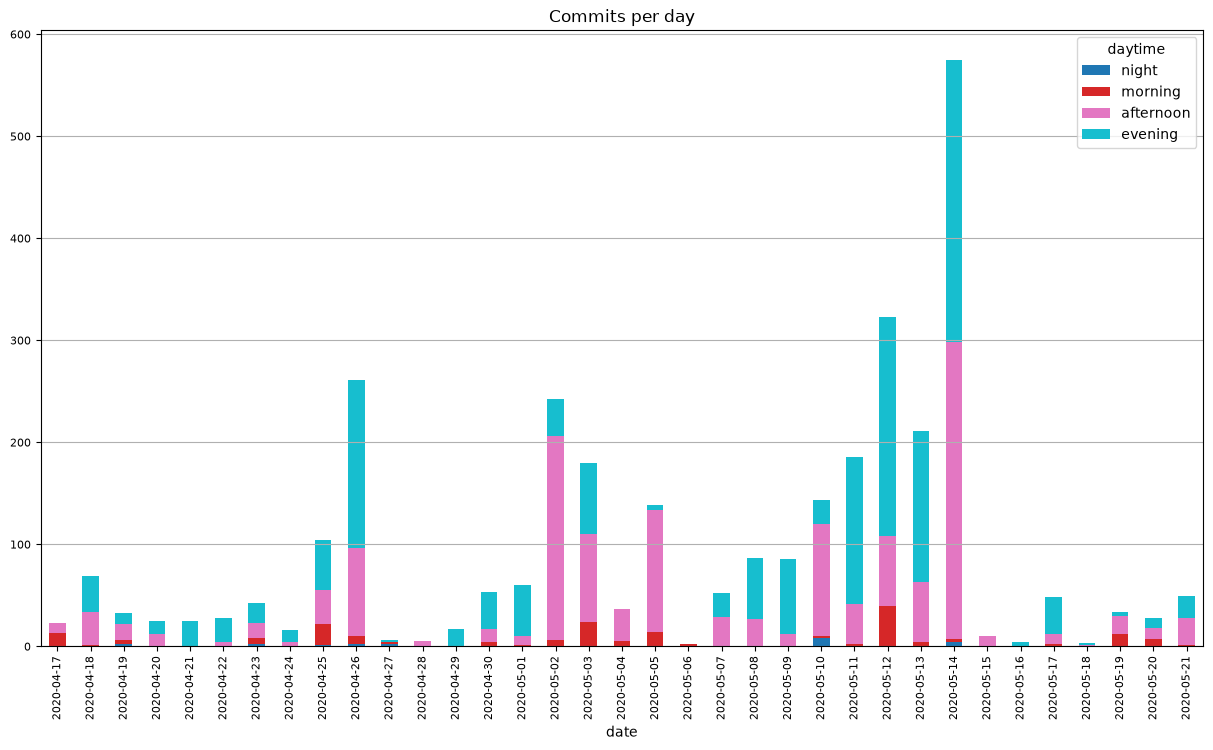

In [9]:
ax = pivot.plot(
    kind='bar',
    stacked=True,
    title='Commits per day',
    fontsize=8,
    figsize=(15, 8),
    colormap='tab10'
)
ax.grid(axis='y')

Когда наши пользователи обычно коммитят: ночью, утром, днём или вечером?

In [10]:
top2 = pivot.sum().sort_values(ascending=False).head(2)
top2

daytime
evening      1611
afternoon    1391
dtype: int64

Какой день имел максимальное число коммитов и при этом вечером коммитов больше, чем днём?

In [11]:
pivot['total'] = pivot.sum(axis=1)

candidates = pivot[pivot['evening'] > pivot['afternoon']]
max_day = candidates['total'].idxmax()

print(f'День: {max_day}')

День: 2020-05-12


In [12]:
conn.close()